In [1]:
import os

# os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"  
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  
from torch import nn


import numpy as np
 
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer  
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt  
import torch.nn.functional as F
import gc
import re
import copy

from tqdm import tqdm

import JCBScope_utils
import JacobianScopes

# Move to GPU with optimal dtype
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = "cpu"

from matplotlib.colors import Normalize as Norm, LogNorm as Log_Norm

### Text-based visualization with colored boxes (like highlighted sentence)
from IPython.display import HTML, display
import matplotlib.colors as mcolors
import matplotlib as mpl


/home/jl3499/conda/LLM1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jl3499/conda/LLM1/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


### Set input strings

In [2]:
front_pad = 2
back_pad = 0

system_prompt = ""

In [3]:


### Dante
# string = "Italiano: Ma quando tu sarai nel dolce mondo, priegoti ch'a la mente altrui mi rechi: English: But when you have returned to the sweet world, I pray you will bring me to men's memory"

### Trilingual translations
# string = "Italian: Buon pomeriggio, i miei colleghi ricercatori. English: Good afternoon, my fellow researchers"
# string = "German: Dies ist ein Aufsatz über kausale Zuschreibung. English: This is a paper on causal attribution"
string = "French: Nous l'appelons lentille jacobienne. English: We call it Jacobian Scope"
# string = "German: Aber ich dachte, da ich ohnehin noch sehr oft zu TED zurückkommen will, könnte ich das vielleicht auf ein anderes Mal verschieben. English: But I was thinking that, since I plan to make a lifelong habit of coming back to TED, that maybe I could talk about that another time"
# string = "\"The lad may be a self-absorbed brat, but he's no devil. Have a drink, Derek. It might loosen you up.\" I watched with disgust as my own father brushed off the thought of having given away his own daughter to the nobleman's son. I gritted my teeth, knowing fully well that the Maslens were far from noble"
### Skip delimiters for time-series data
skip_delimiters = False

In [4]:
Fisher_Scope = 1
Temperature_scope = 1
# method = 'full'
method = 'low_rank'
# method = 'finite_diff'

rank_cut_off = 1
n_hutchinson_samples = 4




### Load models

In [5]:
# Deep clean CUDA GPU memory
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
gc.collect()  



75

In [6]:
# Load the tokenizer and model

model_name = "meta-llama/Llama-3.2-1B"
# model_name = "meta-llama/Llama-3.2-3B"


if device == "cpu":
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model = model.to(device)
else:
    tokenizer = AutoTokenizer.from_pretrained(model_name, device_map="auto")
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")
    
model.eval()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (ro

In [7]:
sys_prompt_tokens = tokenizer(system_prompt, add_special_tokens=False)["input_ids"]

sys_token_len = len(sys_prompt_tokens)

# Get special tokens if available
bos_token_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.cls_token_id
eos_token_id = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else tokenizer.sep_token_id

# Prepare input: pad both ends with special tokens
input_ids_list = []

# Pad the front
if bos_token_id is not None:
    input_ids_list += [bos_token_id] * front_pad

# Add system prompt
input_ids_list += sys_prompt_tokens
# Main tokens
input_ids_list += tokenizer(string, add_special_tokens=False)["input_ids"]

# Pad the back
if eos_token_id is not None:
    input_ids_list += [eos_token_id] * back_pad

input_ids = torch.tensor([input_ids_list], dtype=torch.long).to(model.device)
attention_mask = torch.ones_like(input_ids)

print("input_ids:", input_ids)
print("vocab size:", model.config.vocab_size)
assert input_ids.max() < model.config.vocab_size

seq_len = input_ids.size(1)

# Optional: print tokens
for i, tok in enumerate(input_ids[0]):
    print(i, tok.item(), repr(tokenizer.decode(tok.item(), skip_special_tokens=False)))

decoded_tokens = [tokenizer.decode(token_id.item(), skip_special_tokens=True) for token_id in input_ids[0]]

print(decoded_tokens)


input_ids: tensor([[128000, 128000,  44297,     25,  48109,    326,  53149,    301,   2439,
          48907,   4618,    503,  40051,  26584,     13,   6498,     25,   1226,
           1650,    433,  25537,   1122,  36020]], device='cuda:0')
vocab size: 128256
0 128000 '<|begin_of_text|>'
1 128000 '<|begin_of_text|>'
2 44297 'French'
3 25 ':'
4 48109 ' Nous'
5 326 ' l'
6 53149 "'app"
7 301 'el'
8 2439 'ons'
9 48907 ' lent'
10 4618 'ille'
11 503 ' j'
12 40051 'acob'
13 26584 'ienne'
14 13 '.'
15 6498 ' English'
16 25 ':'
17 1226 ' We'
18 1650 ' call'
19 433 ' it'
20 25537 ' Jacob'
21 1122 'ian'
22 36020 ' Scope'
['', '', 'French', ':', ' Nous', ' l', "'app", 'el', 'ons', ' lent', 'ille', ' j', 'acob', 'ienne', '.', ' English', ':', ' We', ' call', ' it', ' Jacob', 'ian', ' Scope']


In [8]:
### Set which tokens to perform gradients on
### Skip comma delimiters

if skip_delimiters:
    grad_idx = [idx for idx in range(front_pad+sys_token_len,len(decoded_tokens),2)]
else:
    ### all positions
    grad_idx = [idx for idx in range(front_pad+sys_token_len,len(decoded_tokens),1)]

print(grad_idx)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]


### Construct backprop variables

In [9]:
embedding_layer = model.get_input_embeddings()
d_model = embedding_layer.embedding_dim

residual = nn.Parameter(torch.zeros(len(grad_idx), d_model, device=model.device))
presence = torch.ones(len(decoded_tokens), 1, device=model.device)


### Customize forward function

In [10]:
forward_pass = JCBScope_utils.customize_forward_pass(model, residual, presence, input_ids, grad_idx, attention_mask)

In [17]:
import torch



batch_size = 16
# batch_size = 2

loss_position = grad_idx[-1]-1
# loss_position = grad_idx[-1]-12
# loss_position = grad_idx[-1]-6


import time

if Temperature_scope:
    if residual.grad is not None:
        residual.grad = None
    tic = time.time()
    loss, logits = forward_pass(loss_position=loss_position, 
                                hidden_norm_as_loss=True)
    forward_toc = time.time()
    print(f"Time taken for hidden_norm_as_loss forward: {forward_toc - tic:.3f} seconds")
    temperature_grads = torch.autograd.grad(loss, residual, retain_graph=True)[0]
    toc = time.time()
    temperature_mag_per_token = temperature_grads.norm(dim=-1).detach().cpu()
    print(f"Time taken for hidden_norm_as_loss backward: {toc - forward_toc:.3f} seconds")

if Fisher_Scope:
    lm_head = JCBScope_utils.get_lm_head(model)
    n_tokens = len(grad_idx)
    d_model = residual.shape[-1]
    batch_tic = time.time()
    F_all_trace, logits = JacobianScopes.fisher_scope_scores(
        forward_pass, residual, loss_position, lm_head,
        method=method, batch_size=batch_size,k=rank_cut_off,n_hutchinson_samples=n_hutchinson_samples
    )
    batch_toc = time.time()
    print(f"Time for Fisher scope (JacobianScopes): {batch_toc - batch_tic:.3f} seconds")
    # probed_Jacobian not computed when using module; F_all_trace is the per-token Fisher trace
    
    


Time taken for hidden_norm_as_loss forward: 0.069 seconds
Time taken for hidden_norm_as_loss backward: 0.027 seconds
Time for Fisher scope (JacobianScopes): 1.459 seconds


In [18]:
method

'low_rank'

### Plot

In [13]:
def plotter(grad_magnitude, plot_title):
    print(plot_title)
    log_color = 0
    exclude_target = 0
    normalize = 0
    cmap = plt.get_cmap('Blues')

    if exclude_target:
        optimized_tokens = [decoded_tokens[idx] for idx in grad_idx][:-1]
    else: 
        optimized_tokens = [decoded_tokens[idx] for idx in grad_idx]

    tick_label_text = optimized_tokens.copy()
                
    # Normalize grad_magnitude for color mapping
    # INSERT_YOUR_CODE
    # Use the smallest non-zero value for vmin
    nonzero_grad = grad_magnitude[grad_magnitude != 0]
    if len(nonzero_grad) > 0:
        vmin = nonzero_grad.min()
    else:
        vmin = grad_magnitude.min()
    vmax = grad_magnitude.max()
    log_norm = Log_Norm(vmin=vmin, vmax=vmax)
    norm = Norm(vmin=grad_magnitude.min(), vmax=vmax)


    bar_idx = grad_idx.index(loss_position+1)

    if log_color:
        colors = cmap(log_norm(grad_magnitude))
    else:
        colors = cmap(norm(grad_magnitude))

    # Build HTML with colored boxes around each word, using bold font
    def rgba_to_css(rgba):
        """Convert matplotlib RGBA to CSS rgba string"""
        return f"rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {rgba[3]:.2f})"

    def get_text_color(bg_rgba):
        """Return white or black text based on background luminance"""
        luminance = 0.299 * bg_rgba[0] + 0.587 * bg_rgba[1] + 0.114 * bg_rgba[2]
        return "white" if luminance < 0.5 else "black"

    html_parts = []
    for i, (token, color) in enumerate(zip(tick_label_text, colors)):
        bg_color = rgba_to_css(color)
        text_color = get_text_color(color)
        
        # Special styling for target token
        if i == bar_idx:
            # bg_color = "black"
            bg_color = "red"
            text_color = "white"
        
        # Clean up token display (remove leading space for display but keep for meaning)
        # display_token = token if token.strip() else "·"  # show dot for whitespace-only tokens
        # Show dot for tokens that are purely whitespace, but do not remove leading space otherwise
        # display_token = "1"+token 
        display_token = token 
        # print(display_token)
        
        html_parts.append(
            f'<span style="'
            f'background-color: {bg_color}; '
            f'color: {text_color}; '
            # f'padding: 0px 9px; '
            f'padding: 0px 0px; '
            # f'margin: 2px; '
            f'margin: 0px; '
            # f'border-radius: 8px; '
            f'border-radius: 0px; '
            f'font-family: monospace; '
            f'font-size: 16px; '
            f'display: inline-block; '
            f'font-weight: bold;'   # <-- bold font here
            # f'">{display_token}</span>'
            # To prevent collapsing of white spaces when displaying the token—including leading spaces—we can use CSS 'white-space: pre' so all spaces are rendered as-is.
            # This ensures that tokens like ' am' keep their leading space in the browser.
            f'white-space: pre;">{display_token}</span>'
        )

    # === OPTION A: HTML display with fixed width ===
    html_str = f'''
    <div style="
        background: white; 
        padding: 20px; 
        border-radius: 8px; 
        line-height: 2.2;
        # width: 480px;
        width: 550px;
        # width: 1100px;
    ">
        {"".join(html_parts)}
    </div>
    '''
    display(HTML(html_str))


    # Adjust the figure size to better fit the colorbar and avoid cutoff
    fig_bar, ax_bar = plt.subplots(figsize=(0.4, 2.2), dpi=150)
    fig_bar.subplots_adjust(left=0.3, right=0.7, bottom=0.1, top=0.9)

    cbar = mpl.colorbar.ColorbarBase(
        ax_bar,
        cmap=cmap,
        norm=log_norm if log_color else norm,
        orientation='vertical'
    )
    if normalize == True:
        cbar.set_label('Normalized influence', fontsize=12)    
    else:
        cbar.set_label('Influence', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)
    cbar.ax.yaxis.set_ticks_position('left')
    cbar.ax.yaxis.set_label_position('left')
    plt.show()


Fisher Scope


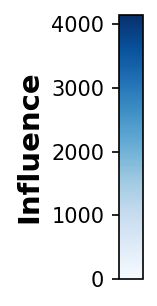

[  73.560905    99.354324    86.6846      11.544959    89.139244
   28.815596    28.477453  1860.1858    4144.7383       9.40679
   36.145893    28.087233    11.7488165   21.305399    10.203553
    6.442619     9.507341     9.912289   520.71875    735.8645
    0.       ]


In [14]:
grad_magnitude = F_all_trace 
plot_title = "Fisher Scope"

plotter(grad_magnitude, plot_title)
print(grad_magnitude)


Temperature Scope


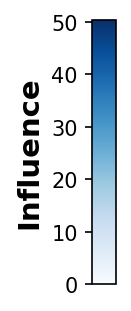

In [15]:
grad_magnitude = temperature_mag_per_token
plot_title = "Temperature Scope"

plotter(grad_magnitude, plot_title)

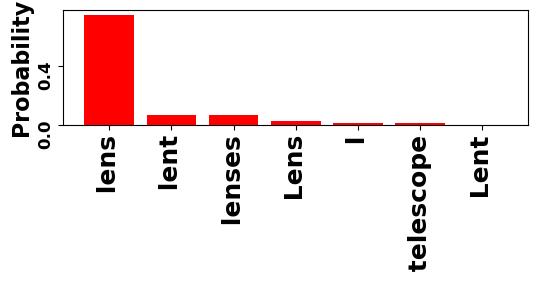

In [16]:
import torch
k = 7
logit_vector = logits[loss_position].detach()             

# Compute softmax probabilities
probs = torch.softmax(logit_vector, dim=-1)

# Get top k probabilities and their indices
top_probs, top_indices = torch.topk(probs, k)
top_tokens = [tokenizer.decode([idx]) for idx in top_indices]

import matplotlib.pyplot as plt

plt.figure(figsize=(6,1.5), dpi=100)
bars = plt.bar(range(k), top_probs.cpu().numpy(), tick_label=top_tokens, color='red')
plt.xticks(rotation=90, fontweight='bold', fontsize=18)
# plt.xlabel('Token',rotation=180, fontweight='bold', fontsize=12)
plt.ylabel('Probability', fontweight='bold', fontsize=16,rotation=90)
plt.yticks(rotation=90, fontweight='bold', fontsize=12)
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(nbins=2))  # increase number of ticks

# plt.title(f'Top {k} Tokens in Softmax of Logits')
plt.show()